# How are in-demand skills trending for Data Analysts?

Methadology

    1. Aggregate skill counts monthly
    2. Analyze based on percentage of total jobs
    3. Plot the likelihood of monthly skill demand


In [49]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Loading dataset from Hugging Face
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

In [50]:
# Data Cleanup

# Convert the date column to a proper datetime format so we can analyze trend over time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert the text strings in the skills column into actual Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [51]:
# Filter the data to strictly look at Data Analyst roles and that into the US Job market
df_DA_US = df[
    (df["job_title"] == "Data Analyst") & (df["job_country"] == "United States")
].copy()

# Extracting Month number column temporarily for sorting data from first month to last
df_DA_US["job_posted_month_no"] = df_DA_US["job_posted_date"].dt.month

In [52]:
# Explode the skills list so we can analyze them individually.
# Then, pivot the data to count exactly how many times each skill was requested in each specific month.
df_DA_US_explode = df_DA_US.explode("job_skills")

df_DA_US_pivot = df_DA_US_explode.pivot_table(
    index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0
)

# creating a temporary Total row
df_DA_US_pivot.loc["Total"] = df_DA_US_pivot.sum()
df_DA_US_pivot

# filter the df by total row
df_DA_US_pivot = df_DA_US_pivot[
    df_DA_US_pivot.loc["Total"].sort_values(ascending=False).index
]

# dropping that temporary total row
df_DA_US_pivot = df_DA_US_pivot.drop("Total")

In [53]:
# Raw counts aren't as useful because some months have more total job postings than others.
# Calculating the percentage of jobs that asked for each skill per month to find the true market trend.
DA_month_totals = df_DA_US.groupby("job_posted_month_no").size()

df_DA_US_per = df_DA_US_pivot.div(DA_month_totals / 100, axis=0).reset_index()

# Adding a month column for seasonal trend analysis to track how skill demand changes over the year.
df_DA_US_per["job_posted_month"] = df_DA_US_per["job_posted_month_no"].apply(
    lambda x: pd.to_datetime(x, format="%m").strftime("%b")
)

# Setting month name column as index and dropping that temporary month number column
df_DA_US_per = df_DA_US_per.set_index("job_posted_month").drop(
    columns="job_posted_month_no"
)
df_DA_US_per.head(3)

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,62.665198,43.006608,35.572687,29.129956,17.951542,21.696035,18.612335,9.306167,9.691630,9.030837,...,0.0,0.0,0.0,0.055066,0.0,0.0,0.0,0.0,0.0,0.0
Feb,60.903427,42.367601,31.775701,29.439252,23.520249,21.028037,18.146417,9.968847,10.124611,7.710280,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Mar,58.883994,42.584435,33.994126,29.368576,20.337739,22.026432,17.694567,10.425844,9.324523,7.856094,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


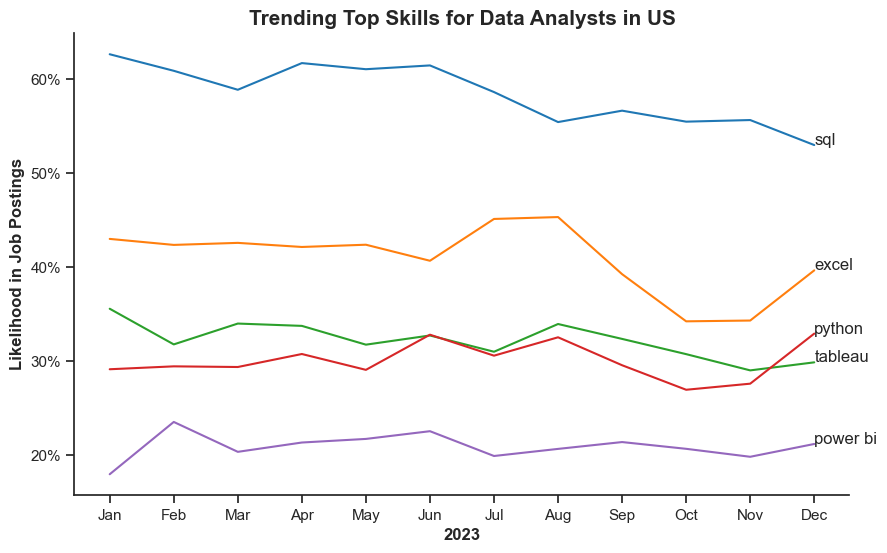

In [54]:
# Plot a line chart showing the momentum of the top 5 most demanded skills throughout the year.
# This helps us see if skills are steady or shifting.

df_plot = df_DA_US_per.iloc[:, :5]
plt.figure(figsize = (10,6))
sns.lineplot(data=df_plot, dashes=False, palette="tab10")
sns.set_theme(style="ticks")

sns.despine()
plt.title("Trending Top Skills for Data Analysts in US", fontsize = 15, weight = 'bold')
plt.ylabel("Likelihood in Job Postings",  weight = 'bold')
plt.xlabel("2023", weight = 'bold')
plt.legend().remove()

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11, df_plot.iloc[-1, i], df_plot.columns[i])

plt.show()

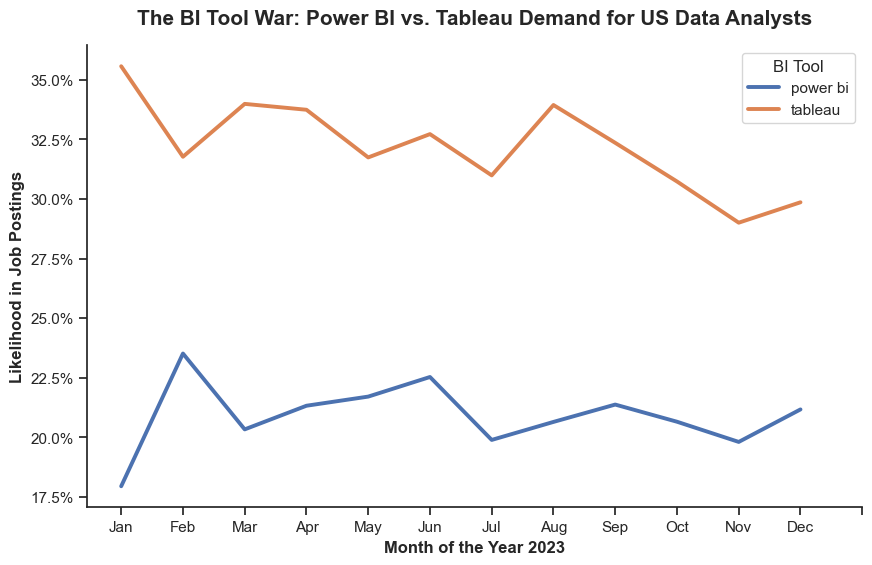

In [55]:
# Narrowing down to BI Tools: Power BI vs. Tableau (For Data Analysts)

# In the business analytics space, the choice of visualization tool is a major strategic decision.
# Filtering the data to directly compare the market momentum of Power BI versus Tableau.

df_plot2 = df_plot[["power bi", "tableau"]]

# Plot the trend
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_plot2,
    dashes=False,
    linewidth=2.8,
)
sns.despine()

# Formatting
plt.title(
    "The BI Tool War: Power BI vs. Tableau Demand for US Data Analysts", fontsize = 15, weight = 'bold',pad=15,
    
)

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=1)) # for getting percentage in y axis

plt.xlabel("Month of the Year 2023", fontsize=12, weight = 'bold')
plt.ylabel("Likelihood in Job Postings", fontsize=12, weight = 'bold')
plt.legend(title="BI Tool", loc="upper right")
plt.xticks(range(0, 13))
plt.show()

### 💡 Market Insight:

Seeing the trend for year 2023, While the broader market utilizes a mix of reporting tools, isolating the demand for Power BI versus Tableau for Data Analysts reveals a critical enterprise software trend. Power BI frequently shows aggressive market adoption, heavily driven by its seamless integration with the Microsoft ecosystem (like Excel and Azure) which is deeply embedded in modern operations. For a Data Analyst prioritizing skill ROI, mastering Power BI offers a significant strategic advantage when applying to enterprise-level analytics teams.
